In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('credit_risk_dataset.csv')

# Look at the first 5 rows
print(df.head())

# Check for missing values and data types
print(df.info())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


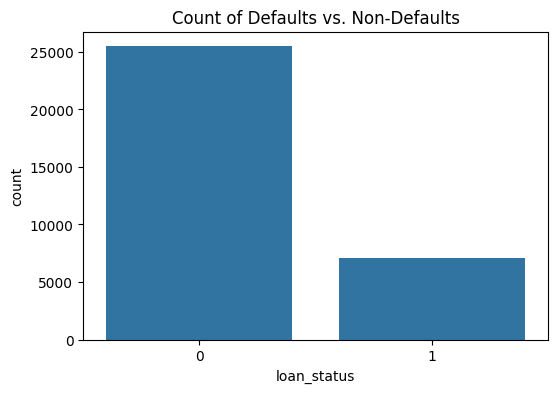

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


In [2]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df)
plt.title('Count of Defaults vs. Non-Defaults')
plt.show()

# Get the exact percentage
print(df['loan_status'].value_counts(normalize=True) * 100)

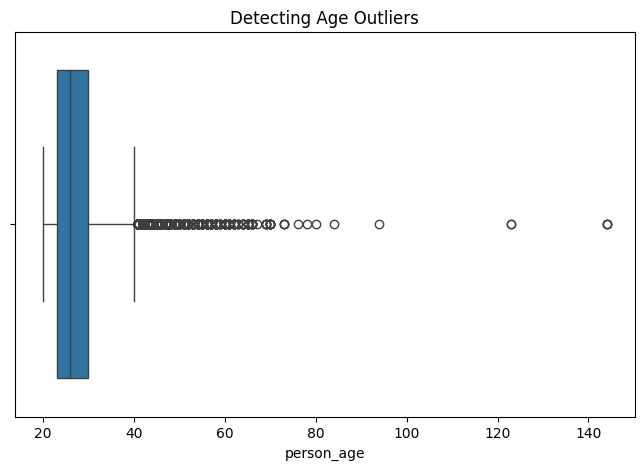

Max Age: 144
Max Employment Length: 123.0


In [3]:
# Check for impossible ages
plt.figure(figsize=(8,5))
sns.boxplot(x=df['person_age'])
plt.title('Detecting Age Outliers')
plt.show()

# Find the maximum values
print("Max Age:", df['person_age'].max())
print("Max Employment Length:", df['person_emp_length'].max())

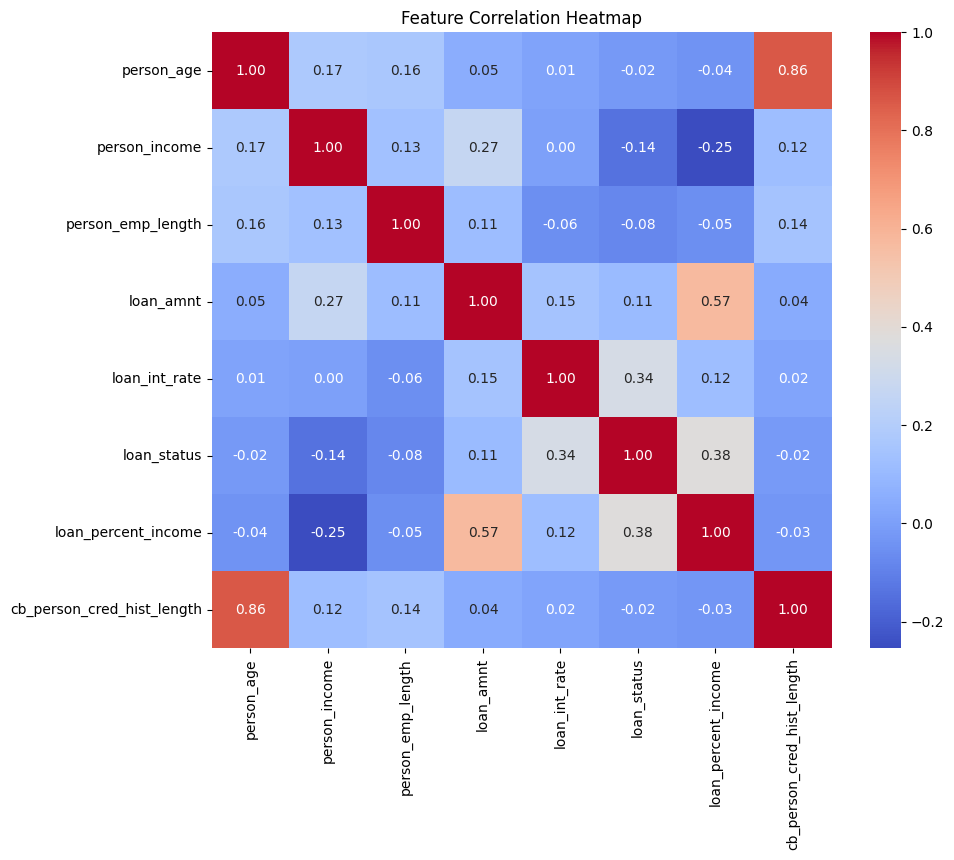

In [4]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])
correlation = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [5]:
# Remove rows with impossible ages
df = df[df['person_age'] < 90]

# Remove rows with impossible employment length
df = df[df['person_emp_length'] < 60]

print(f"New Max Age: {df['person_age'].max()}")

New Max Age: 84


In [6]:
# Fill missing employment length with median
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Fill missing interest rate (if any) with median
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [7]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns to convert: {list(cat_cols)}")

# Convert text to numbers using One-Hot Encoding
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("\nShape of data after encoding:", df_final.shape)
print(df_final.head())

Categorical columns to convert: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Shape of data after encoding: (31678, 23)
   person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
1          21           9600                5.0       1000          11.14   
2          25           9600                1.0       5500          12.87   
3          23          65500                4.0      35000          15.23   
4          24          54400                8.0      35000          14.27   
5          21           9900                2.0       2500           7.14   

   loan_status  loan_percent_income  cb_person_cred_hist_length  \
1            0                 0.10                           2   
2            1                 0.57                           3   
3            1                 0.53                           2   
4            1                 0.55                           4   
5            1                 0.25        

C:\Users\jayan\AppData\Local\Temp\ipykernel_5172\1685487061.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [8]:
from sklearn.model_selection import train_test_split

# X = Everything except the target
X = df_final.drop('loan_status', axis=1)

# y = Only the target
y = df_final['loan_status']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 25342
Testing set size: 6336


In [9]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply only to the TRAINING data (never the test data!)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\n--- After SMOTE ---")
print(y_train_res.value_counts())


--- After SMOTE ---
loan_status
0    19888
1    19888
Name: count, dtype: int64


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and Train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# Make Predictions
y_pred = rf_model.predict(X_test)

# Evaluate
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Confusion Matrix ---
[[4833  132]
 [ 379  992]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      4965
           1       0.88      0.72      0.80      1371

    accuracy                           0.92      6336
   macro avg       0.90      0.85      0.87      6336
weighted avg       0.92      0.92      0.92      6336



In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,classification_report

#Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_res, y_train_res)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

#ROC-AUC
roc_lr = roc_auc_score(y_test,y_prob_lr)
roc_rf = roc_auc_score(y_test,y_prob_rf)

print("ROC-AUC (Logistic Regression):",roc_lr)
print("ROC-AUC (Random Forest):",roc_rf)

ROC-AUC (Logistic Regression): 0.8080840133303658
ROC-AUC (Random Forest): 0.9241453118584283


c:\Users\jayan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
threshold = 0.3 
y_pred_custom = (y_prob_rf > threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix (Threshold = 0.3):")
print(confusion_matrix(y_test, y_pred_custom))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom))

Confusion Matrix (Threshold = 0.3):
[[4523  442]
 [ 283 1088]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      4965
           1       0.71      0.79      0.75      1371

    accuracy                           0.89      6336
   macro avg       0.83      0.85      0.84      6336
weighted avg       0.89      0.89      0.89      6336



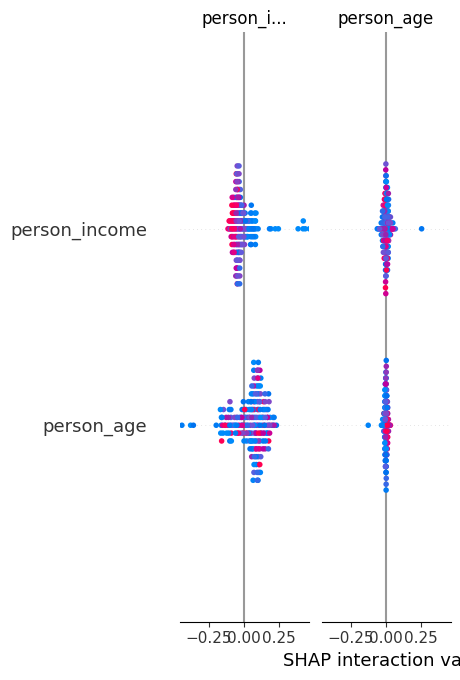

In [14]:
import shap

X_sample = X_test.sample(200,random_state = 42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample)

### SHAP Interpretation

- Income is the most influential feature in predicting credit risk.
- Higher income generally reduces the probability of default.
- Age also contributes but with lower impact.
- The model relies more on financial indicators than demographic ones.

In [15]:
import joblib

# 1. Save the trained model
joblib.dump(rf_model, 'credit_risk_model.pkl')

# 2. Save the column names (very important for alignment later)
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')

print("Model and Columns saved successfully!")

Model and Columns saved successfully!


In [16]:
import joblib
# The 'compress' parameter significantly reduces file size
joblib.dump(rf_model, 'credit_risk_model.pkl', compress=3)

['credit_risk_model.pkl']